# **Import**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import GaussianNB
import joblib
from sklearn.tree import plot_tree
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier

# **Leitura do dataset **

In [ ]:
dfSpyware = pd.read_csv("dataset_spyware_binary_float32.csv")

# **Padronização e separação dos dados**

In [ ]:
X = dfSpyware.drop(columns=['Category'])
Y = dfSpyware['Category']

In [ ]:
scaler = StandardScaler()
X_standardized_array = scaler.fit_transform(X)
X_standardized = pd.DataFrame(
    X_standardized_array,
    columns=X.columns
)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X_standardized,Y,test_size=0.2,random_state=42,stratify=Y)

# **Random Forest**

In [ ]:
modelRandomForest = RandomForestClassifier(
    random_state=42,
    n_estimators=10,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=10
)
modelRandomForest.fit(X_train, Y_train)

RandomForestClassifier(max_depth=20, min_samples_leaf=10, min_samples_split=10,
                       n_estimators=10, random_state=42)

In [ ]:
y_predRF = modelRandomForest.predict(X_test)
acc = accuracy_score(Y_test, y_predRF)
print(f"Acurácia: {acc:.4f}")
f1 = f1_score(Y_test, y_predRF, average='weighted')
print(f"F1-Score (weighted): {f1:.4f}")

Acurácia: 0.9985
F1-Score (weighted): 0.9985


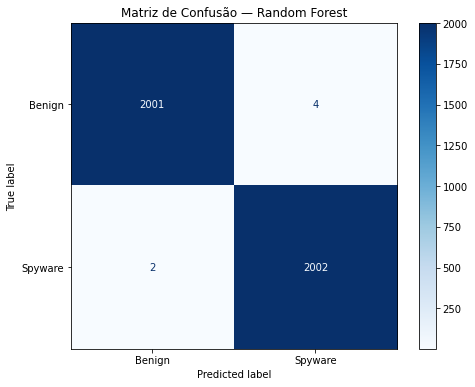

In [ ]:
cm = confusion_matrix(Y_test, y_predRF)
labels = ['Benign', 'Spyware']
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)
fig, ax = plt.subplots(figsize=(8,6))
disp.plot(
    cmap=plt.cm.Blues,
    ax=ax
)
plt.title("Matriz de Confusão — Random Forest")
plt.savefig(
    "matriz_confusao_random_forest.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [ ]:
joblib.dump(modelRandomForest, 'modelo_random_forest.pkl')

['modelo_random_forest.pkl']

In [ ]:
y_predRF = modelRandomForest.predict(X_test)
print("Relatório de classificação:\n")
print(classification_report(Y_test, y_predRF,digits=5))

Relatório de classificação:

              precision    recall  f1-score   support

           0    0.99900   0.99800   0.99850      2005
           1    0.99801   0.99900   0.99850      2004

    accuracy                        0.99850      4009
   macro avg    0.99850   0.99850   0.99850      4009
weighted avg    0.99850   0.99850   0.99850      4009



K-fold

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(modelRandomForest, X, Y, cv=cv, scoring='f1_weighted')
print("CV F1-scores por fold:", scores)
print("F1-Score médio (CV):", np.mean(scores))
print("F1-Score Desvio padrão (CV):", np.std(scores))

CV F1-scores por fold: [0.99900249 0.99950125 0.99800499 0.99900249 1.         1.
 0.99800398 1.         0.999501   0.999002  ]
F1-Score médio (CV): 0.9992018197165636
F1-Score Desvio padrão (CV): 0.0007125341432597439


In [ ]:
acc_scores = cross_val_score(modelRandomForest, X, Y, cv=cv, scoring='accuracy')
print("CV Acurácia por fold:", acc_scores)
print("Acurácia média (CV):", np.mean(acc_scores))
print("Acurácia Desvio padrão (CV):", np.std(acc_scores))

CV Acurácia por fold: [0.99900249 0.99950125 0.99800499 0.99900249 1.         1.
 0.99800399 1.         0.999501   0.999002  ]
Acurácia média (CV): 0.999201820797308
Acurácia Desvio padrão (CV): 0.0007125327525393428


# **Naive Bayes**

In [ ]:
modelNB = GaussianNB()
modelNB.fit(X_train, Y_train)
y_predNB = modelNB.predict(X_test)

In [ ]:
acc = accuracy_score(Y_test, y_predNB)
print(f"Accuracy (Naive Bayes): {acc:.4f}")

f1 = f1_score(Y_test, y_predNB, average='weighted')
print(f"F1-Score (weighted, Naive Bayes): {f1:.4f}")

Accuracy (Naive Bayes): 0.9910
F1-Score (weighted, Naive Bayes): 0.9910


In [ ]:
print("Relatório de classificação:\n")
print(classification_report(Y_test, y_predNB,digits=5))

Relatório de classificação:

              precision    recall  f1-score   support

           0    0.99547   0.98653   0.99098      2005
           1    0.98665   0.99551   0.99106      2004

    accuracy                        0.99102      4009
   macro avg    0.99106   0.99102   0.99102      4009
weighted avg    0.99106   0.99102   0.99102      4009



In [ ]:
joblib.dump(modelNB, 'modelo_NaiveBayes.pkl')

['modelo_NaiveBayes.pkl']

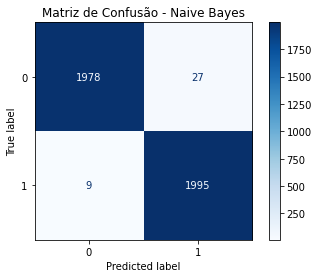

In [ ]:
cm = confusion_matrix(Y_test, y_predNB)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - Naive Bayes")
plt.savefig("matriz_confusao_naiveBayes.png", dpi=300, bbox_inches='tight')
plt.show()

K-fold

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
f1_scores = cross_val_score(modelNB, X, Y, cv=cv, scoring='f1_weighted')
print("CV F1-scores por fold:", f1_scores)
print("F1-Score médio (CV):", np.mean(f1_scores))
print("F1-Score desvio (CV):", np.std(f1_scores))

CV F1-scores por fold: [0.99251869 0.99401483 0.98753089 0.9910221  0.98852288 0.99401183
 0.99151671 0.9920159  0.99001992 0.99351284]
F1-Score médio (CV): 0.9914686589162247
F1-Score desvio (CV): 0.002121687582763389


In [ ]:
acc_scores = cross_val_score(modelNB, X, Y, cv=cv, scoring='accuracy')
print("CV Acurácia por fold:", acc_scores)
print("Acurácia média (CV):", np.mean(acc_scores))
print("Acurácia desvio (CV):", np.std(acc_scores))

CV Acurácia por fold: [0.9925187  0.99401496 0.98753117 0.99102244 0.98852295 0.99401198
 0.99151697 0.99201597 0.99001996 0.99351297]
Acurácia média (CV): 0.9914688080198705
Acurácia desvio (CV): 0.0021216653439410644


# **MLP**

In [ ]:
model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=20,
    batch_size=64,
    random_state=42,
    verbose=True
)

In [ ]:
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)

Iteration 1, loss = 0.04381520
Iteration 2, loss = 0.00411681
Iteration 3, loss = 0.00229338
Iteration 4, loss = 0.00188698
Iteration 5, loss = 0.00126655
Iteration 6, loss = 0.00337066
Iteration 7, loss = 0.00083571
Iteration 8, loss = 0.00041516
Iteration 9, loss = 0.00030507
Iteration 10, loss = 0.00030862
Iteration 11, loss = 0.00027781
Iteration 12, loss = 0.00022598
Iteration 13, loss = 0.00024875
Iteration 14, loss = 0.00022103
Iteration 15, loss = 0.00022273
Iteration 16, loss = 0.00019554
Iteration 17, loss = 0.00019328
Iteration 18, loss = 0.00018551
Iteration 19, loss = 0.00018179
Iteration 20, loss = 0.00017919
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


In [ ]:
acc = accuracy_score(Y_test, y_pred)
print(f"Acurácia: {acc:.4f}")
f1 = f1_score(Y_test, y_pred, average='weighted')
print(f"F1-Score (weighted): {f1:.4f}")

Acurácia: 0.9998
F1-Score (weighted): 0.9998


In [ ]:
joblib.dump(model, 'modelMLP1.pkl')

['modelMLP1.pkl']

In [ ]:
y_pred = model.predict(X_test)
print("Relatório de classificação:\n")
print(classification_report(Y_test, y_pred,digits=5))

Relatório de classificação:

              precision    recall  f1-score   support

           0    0.99950   1.00000   0.99975      2005
           1    1.00000   0.99950   0.99975      2004

    accuracy                        0.99975      4009
   macro avg    0.99975   0.99975   0.99975      4009
weighted avg    0.99975   0.99975   0.99975      4009



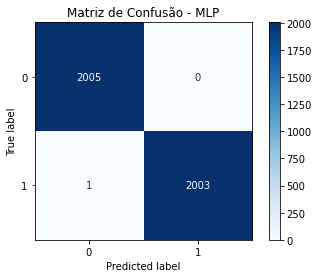

In [ ]:
cm = confusion_matrix(Y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - MLP")
plt.savefig("matriz_confusaoMLP.png", dpi=300, bbox_inches='tight')
plt.show()

K-Fold

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(model, X, Y, cv=cv, scoring='f1_weighted')
print("F1-scores por fold:", scores)
print("F1-Score médio (CV):", np.mean(scores))
print("F1-Score Desvio (CV):", np.std(scores))

Iteration 1, loss = 1.75345707
Iteration 2, loss = 0.72769605
Iteration 3, loss = 0.28725485
Iteration 4, loss = 0.18135976
Iteration 5, loss = 0.63366484
Iteration 6, loss = 0.26512641
Iteration 7, loss = 0.09674153
Iteration 8, loss = 0.13902639
Iteration 9, loss = 0.09531705
Iteration 10, loss = 0.46023929
Iteration 11, loss = 0.12073623
Iteration 12, loss = 0.32431081
Iteration 13, loss = 0.09759225
Iteration 14, loss = 0.11192413
Iteration 15, loss = 0.07429206
Iteration 16, loss = 0.10168362
Iteration 17, loss = 0.17410884
Iteration 18, loss = 0.08016815
Iteration 19, loss = 0.05315388
Iteration 20, loss = 0.08186063


Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.


Iteration 1, loss = 1.44534691
Iteration 2, loss = 0.61197146
Iteration 3, loss = 0.45454522
Iteration 4, loss = 0.15223014
Iteration 5, loss = 0.36751776
Iteration 6, loss = 0.44381650
Iteration 7, loss = 0.09136374
Iteration 8, loss = 0.18079508
Iteration 9, loss = 0.10277701
Iteration 10, loss = 0.39786157
Iteration 11, loss = 0.14943206
Iteration 12, loss = 0.12344389
Iteration 13, loss = 0.08075783
Iteration 14, loss = 0.10844120
Iteration 15, loss = 0.25339799
Iteration 16, loss = 0.06909565
Iteration 17, loss = 0.08585593
Iteration 18, loss = 0.06444537
Iteration 19, loss = 0.06277236
Iteration 20, loss = 0.09537369


Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.


Iteration 1, loss = 1.64865230
Iteration 2, loss = 0.50788566
Iteration 3, loss = 0.46679548
Iteration 4, loss = 0.23683790
Iteration 5, loss = 0.06507650
Iteration 6, loss = 0.34734370
Iteration 7, loss = 0.72359393
Iteration 8, loss = 0.25670574
Iteration 9, loss = 0.14873307
Iteration 10, loss = 0.70470547
Iteration 11, loss = 0.18727983
Iteration 12, loss = 0.07411120
Iteration 13, loss = 0.05623755
Iteration 14, loss = 0.05660925
Iteration 15, loss = 0.06124168
Iteration 16, loss = 0.07309525
Iteration 17, loss = 0.07481834
Iteration 18, loss = 0.05845905
Iteration 19, loss = 0.11456368
Iteration 20, loss = 0.13088078


...

Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.


Iteration 1, loss = 1.62349660
Iteration 2, loss = 0.37224599
Iteration 3, loss = 0.63860474
Iteration 4, loss = 0.20577461
Iteration 5, loss = 0.17686067
Iteration 6, loss = 0.16145625
Iteration 7, loss = 0.19823451
Iteration 8, loss = 0.15015968
Iteration 9, loss = 0.56324739
Iteration 10, loss = 0.33064524
Iteration 11, loss = 0.12398718
Iteration 12, loss = 0.15315060
Iteration 13, loss = 0.07933070
Iteration 14, loss = 0.07887490
Iteration 15, loss = 0.45577800
Iteration 16, loss = 0.07613968
Iteration 17, loss = 0.05797992
Iteration 18, loss = 0.06300673
Iteration 19, loss = 0.06255006
Iteration 20, loss = 0.04696142
Iteration 1, loss = 2.50683101


Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.


Iteration 2, loss = 0.21940658
Iteration 3, loss = 0.17240533
Iteration 4, loss = 0.67456249
Iteration 5, loss = 0.15511210
Iteration 6, loss = 0.34405774
Iteration 7, loss = 0.27318437
Iteration 8, loss = 0.19244517
Iteration 9, loss = 0.08693387
Iteration 10, loss = 0.23574262
Iteration 11, loss = 0.58665022
Iteration 12, loss = 0.08523056
Iteration 13, loss = 0.08921257
Iteration 14, loss = 0.09452837
Iteration 15, loss = 0.13282362
Iteration 16, loss = 0.09648047
Iteration 17, loss = 0.10203034
Iteration 18, loss = 0.07182523
Iteration 19, loss = 0.05709166
Iteration 20, loss = 0.14929835
F1-scores por fold: [0.99501247 0.99650873 0.98952608 0.99301727 0.99201546 0.99650696
 0.97303969 0.99550893 0.99301386 0.99550893]
F1-Score médio (CV): 0.991965836307273
F1-Score Desvio (CV): 0.006648357284182157


Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.


In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
acc_scores = cross_val_score(model, X, Y, cv=cv, scoring='accuracy')
print("CV Acurácia por fold:", acc_scores)
print("Acurácia média (CV):", np.mean(acc_scores))
print("Acurácia desvio (CV):", np.std(acc_scores))

Iteration 1, loss = 1.75345707
Iteration 2, loss = 0.72769605
Iteration 3, loss = 0.28725485
Iteration 4, loss = 0.18135976
Iteration 5, loss = 0.63366484
Iteration 6, loss = 0.26512641
Iteration 7, loss = 0.09674153
Iteration 8, loss = 0.13902639
Iteration 9, loss = 0.09531705
Iteration 10, loss = 0.46023929
Iteration 11, loss = 0.12073623
Iteration 12, loss = 0.32431081
Iteration 13, loss = 0.09759225
Iteration 14, loss = 0.11192413
Iteration 15, loss = 0.07429206
Iteration 16, loss = 0.10168362
Iteration 17, loss = 0.17410884
Iteration 18, loss = 0.08016815
Iteration 19, loss = 0.05315388
Iteration 20, loss = 0.08186063
Iteration 1, loss = 1.44534691


Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.


Iteration 2, loss = 0.61197146
Iteration 3, loss = 0.45454522
Iteration 4, loss = 0.15223014
Iteration 5, loss = 0.36751776
Iteration 6, loss = 0.44381650
Iteration 7, loss = 0.09136374
Iteration 8, loss = 0.18079508
Iteration 9, loss = 0.10277701
Iteration 10, loss = 0.39786157
Iteration 11, loss = 0.14943206
Iteration 12, loss = 0.12344389
Iteration 13, loss = 0.08075783
Iteration 14, loss = 0.10844120
Iteration 15, loss = 0.25339799
Iteration 16, loss = 0.06909565
Iteration 17, loss = 0.08585593
Iteration 18, loss = 0.06444537
Iteration 19, loss = 0.06277236
Iteration 20, loss = 0.09537369
Iteration 1, loss = 1.64865230


Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.


Iteration 2, loss = 0.50788566
Iteration 3, loss = 0.46679548
Iteration 4, loss = 0.23683790
Iteration 5, loss = 0.06507650
Iteration 6, loss = 0.34734370
Iteration 7, loss = 0.72359393
Iteration 8, loss = 0.25670574
Iteration 9, loss = 0.14873307
Iteration 10, loss = 0.70470547
Iteration 11, loss = 0.18727983
Iteration 12, loss = 0.07411120
Iteration 13, loss = 0.05623755
Iteration 14, loss = 0.05660925
Iteration 15, loss = 0.06124168
Iteration 16, loss = 0.07309525
Iteration 17, loss = 0.07481834
Iteration 18, loss = 0.05845905
Iteration 19, loss = 0.11456368
Iteration 20, loss = 0.13088078
Iteration 1, loss = 1.28557774


...

Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.


Iteration 1, loss = 1.62349660
Iteration 2, loss = 0.37224599
Iteration 3, loss = 0.63860474
Iteration 4, loss = 0.20577461
Iteration 5, loss = 0.17686067
Iteration 6, loss = 0.16145625
Iteration 7, loss = 0.19823451
Iteration 8, loss = 0.15015968
Iteration 9, loss = 0.56324739
Iteration 10, loss = 0.33064524
Iteration 11, loss = 0.12398718
Iteration 12, loss = 0.15315060
Iteration 13, loss = 0.07933070
Iteration 14, loss = 0.07887490
Iteration 15, loss = 0.45577800
Iteration 16, loss = 0.07613968
Iteration 17, loss = 0.05797992
Iteration 18, loss = 0.06300673
Iteration 19, loss = 0.06255006
Iteration 20, loss = 0.04696142


Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.


Iteration 1, loss = 2.50683101
Iteration 2, loss = 0.21940658
Iteration 3, loss = 0.17240533
Iteration 4, loss = 0.67456249
Iteration 5, loss = 0.15511210
Iteration 6, loss = 0.34405774
Iteration 7, loss = 0.27318437
Iteration 8, loss = 0.19244517
Iteration 9, loss = 0.08693387
Iteration 10, loss = 0.23574262
Iteration 11, loss = 0.58665022
Iteration 12, loss = 0.08523056
Iteration 13, loss = 0.08921257
Iteration 14, loss = 0.09452837
Iteration 15, loss = 0.13282362
Iteration 16, loss = 0.09648047
Iteration 17, loss = 0.10203034
Iteration 18, loss = 0.07182523
Iteration 19, loss = 0.05709166
Iteration 20, loss = 0.14929835
CV Acurácia por fold: [0.99501247 0.99650873 0.98952618 0.99301746 0.99201597 0.99650699
 0.97305389 0.99550898 0.99301397 0.99550898]
Acurácia média (CV): 0.9919673620340366
Acurácia desvio (CV): 0.0066443220395241915


Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.


# **Shap do melhor modelo selecionado**

PermutationExplainer explainer: 4010it [02:29, 25.45it/s]                          


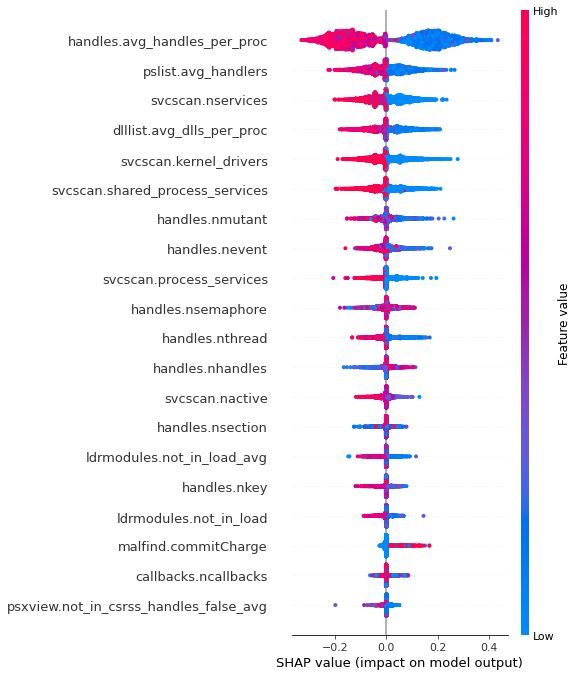

In [ ]:
explainer = shap.Explainer(modelRandomForest.predict, X_test)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test, plot_type="dot")